<a href="https://colab.research.google.com/github/Itscskh/genai-bootcamp-lab1/blob/main/W3S4_Lab_Multimodal_App_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:linear-gradient(135deg,#16304A 0%,#003C9C 100%);border-radius:14px;padding:22px 26px;color:#fff;font-family:Segoe UI,Arial,sans-serif;">
  <div style="display:flex;justify-content:space-between;align-items:center;gap:16px;">
    <div>
      <div style="font-size:13px;letter-spacing:1px;opacity:.85;text-transform:uppercase;">Generative AI Summer Bootcamp &middot; Najran University</div>
      <div style="font-size:26px;font-weight:800;margin-top:4px;">Lab — Build, Optimize & Deploy a Multimodal App</div>
      <div style="font-size:15px;opacity:.92;margin-top:4px;">Week 3 · Session 4 — Multimodal Pipelines + NVIDIA Stack & Optimization</div>
    </div>
    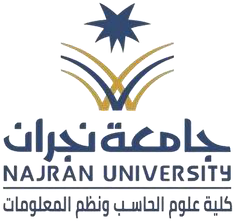
  </div>
  <div style="margin-top:16px;display:flex;gap:10px;flex-wrap:wrap;font-size:13px;">
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">🏆 NCA-GENM track</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">⏱️ Lab: ≈ 45 minutes</span>
    <span style="background:rgba(255,255,255,.16);padding:5px 12px;border-radius:20px;">▶️ Runs on Google Colab (free)</span>
  </div>
</div>

<a target="_blank" href="https://colab.research.google.com/"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:16px;margin-bottom:6px;">🎓 Learning objectives</div>
<ul style="margin:0;padding-left:20px;font-size:15px;color:#16304A;"><li style="margin:5px 0;">Chain two modalities: <b>image → caption</b> (BLIP) → <b>short story</b> (Qwen2.5).</li>
<li style="margin:5px 0;">Load the LLM in <b>4-bit</b> with bitsandbytes and compare <b>VRAM & latency</b> vs FP16.</li>
<li style="margin:5px 0;">Wrap the pipeline in a <b>Gradio</b> app and <b>make it your own</b> (your name + your story style).</li>
<li style="margin:5px 0;">Deploy your personalised app as a shareable <b>Hugging Face Space</b> to show the class.</li></ul></div>

## How to use this notebook

Run the cells **in order**, top to bottom (`Shift+Enter`). Read the short notes before each part — they connect the code back to today's slides. This is the **Week-3 capstone**: you build one small end-to-end app, make it smaller with quantization, then prepare it for deployment.

<div style="border:1px solid #16304A33;border-left:6px solid #16304A;background:#EDF1F6;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#16304A;font-size:15px;margin-bottom:4px;">🔧 First: turn on the free GPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Click <b>Runtime → Change runtime type → T4 GPU → Save</b>. Quantization with bitsandbytes <b>requires a CUDA GPU</b>, so this step is mandatory today.</div></div>

### Setup
Colab already ships PyTorch. We add Transformers, bitsandbytes (quantization), accelerate, Gradio, and Pillow for images. This takes ~1–2 minutes the first time. If pip prints any red dependency warnings, you can safely ignore them.

In [1]:
# 1. Install compatible packages to avoid dependency conflicts
!pip -q install "transformers>=4.45.0" "accelerate>=0.33" "bitsandbytes>=0.45.0" "gradio>=4.40.0" pillow requests

import torch
import warnings
warnings.filterwarnings("ignore")

print("Setup complete successfully! Move to the next cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.6 MB/s eta 0:00:00
Setup complete successfully! Move to the next cell.


In [2]:
# Sanity check: confirm we are on a GPU (this lab and bitsandbytes 4-bit both need one)
import torch
print("PyTorch:", torch.__version__)
assert torch.cuda.is_available(), "No GPU! Runtime -> Change runtime type -> T4 GPU -> Save, then re-run."
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU: Tesla T4


## Part 1 — Modality 1: image → caption (BLIP)

Our first stage turns an **image into text**. We use `Salesforce/blip-image-captioning-base` — an open, ungated vision-language model (~1 GB). First we download a sample image.

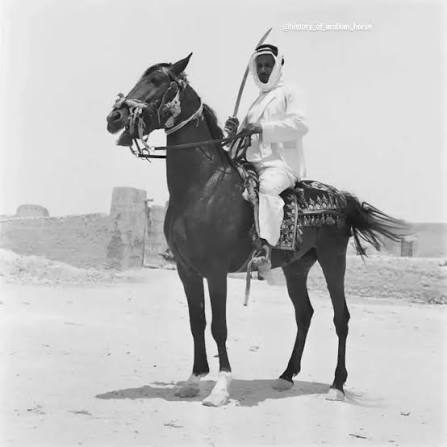

In [4]:
import requests
from io import BytesIO
from PIL import Image

# A public sample image (a dog). Replace the URL with any image you like.
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTVW_-FaMygU7d-GnLCSp9ixi6ktegQJZIR1AoTsiUYjfef3IwqhVS_zxw&s=10"
image = Image.open(BytesIO(requests.get(url, timeout=15).content)).convert("RGB")
image  # Colab displays the image inline

In [5]:
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_id = "Salesforce/blip-image-captioning-base"
blip_processor = BlipProcessor.from_pretrained(blip_id)
blip_model = BlipForConditionalGeneration.from_pretrained(
    blip_id, dtype=torch.float16
).to("cuda")
print("BLIP loaded.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP loaded.


In [6]:
def caption_image(img):
    inputs = blip_processor(img, return_tensors="pt").to("cuda", torch.float16)
    out = blip_model.generate(**inputs, max_new_tokens=30)
    return blip_processor.decode(out[0], skip_special_tokens=True)

caption = caption_image(image)
print("Caption:", caption)

Caption: a man in a white robe riding a horse


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ This is the 'glue'</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The caption is plain <b>text</b>. That text is exactly what we hand to the LLM in the next stage — text is the common interface that lets us chain two different models together.</div></div>

## Part 2 — Modality 2: caption → short story (Qwen2.5)

The second stage is a text LLM, `Qwen/Qwen2.5-1.5B-Instruct` (open, ungated). It takes the caption and writes a short story. We load it in **FP16** first (the Colab default).

In [7]:
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig
import torch

# Configure 4-bit quantization settings to optimize VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load Qwen2-VL-2B processor and the correct model class
vlm_id = "Qwen/Qwen2-VL-2B-Instruct"
print("Loading vision model (this may take about a minute)...")
vlm_processor = AutoProcessor.from_pretrained(vlm_id)

# FIXED: Replaced AutoModelForCausalLM with Qwen2VLForConditionalGeneration
vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    vlm_id,
    quantization_config=bnb_config,
    device_map="cuda"
)

print("Vision model loaded successfully!")

Loading vision model (this may take about a minute)...


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Vision model loaded successfully!


In [14]:
AL_DIWAN_DB = {
    "قهوة": {
        "فصيح": "أَدِرْ كَأْسَ رَشْفٍ مِثْلَ ذَوْبِ العَقِيقِ... وَقَدِّمْ لَنَا المَزْجَ الذَّكِيَّ العَتِيقِ\nفَفِي رَشْفَةِ السُّمْرِ العَذِيْبِ سَعَادَةٌ... تُزِيْحُ هُمُومَ النَّفْسِ عَنْ كُلِّ ضِيقِ",
        "نبطي": "يا محلا الفنجال مع سيحة البال... في مجلساً ما فيه نفسٍ ثقيله\nصبه لشخصٍ تالي العمر يشتال... هموم بقعا والظروف المليله"
    },
    "صقر": {
        "فصيح": "كَأَنَّ الصَّقْرَ فِي العَلْيَاءِ مَلِكٌ... يَجُوبُ الأُفْقَ فِي عِزٍّ وَفَخْرِ\nإِذَا مَا لَاحَ صَيْدٌ فِي بَقَاعٍ... هَوَى كَالمَوْتِ مِنْ عَدْوٍ وَذُعْرِ",
        "نبطي": "يا طير عقب البطا أدليت حومك... في مظهرٍ كل الصقاقير تطريه\nأفرد جنااحك والنواميس تومك... صيد الخلا في ماكرك لا تخليه"
    },
    "خيل": {
        "فصيح": "الخَيْلُ وَاللَّيْلُ وَالبَيْدَاءُ تَعْرِفُنِي... وَالسَّيْفُ وَالرُّمْحُ وَالقِرْطَاسُ وَالقَلَمُ\nصَحِبْتُهَا وَشَبَابُ العُمْرِ فِي أَنَقٍ... فَمَا وَجَدْتُ سِوَى الأَمْجَادِ تَبْتَسِمُ",
        "نبطي": "يا سابقٍ ملحا من الخيل جلاّل... خيالها وقت الملاقى يمارى\nتسبق هبوب الريح في كل مضمار... وعيوننا من زهر حسنك حيارى"
    },
    "صحراء": {
        "فصيح": "وَبَيْدَاءَ لَمْ تَسْكُنْ بِهَا النَّاسُ قَبْلَنَا... سَرَيْنَا بِهَا وَاللَّيْلُ رَامٍ كَوَاكِبَهْ\nنَسِيرُ عَلَى أَنْوَارِهَا وَنَجُوبُهَا... وَكُلُّ فَتًى يَرْجُو مَنَالاً يُصَاحِبَهْ",
        "نبطي": "يا زين مشيٍ في الفيافي الخليه... في ديرةٍ ما داسها كل دجّال\nبأرضٍ خلا ما طبّها الآدميه... يسوى حياة القصر مع صف الأموال"
    },
    "مطر": {
        "فصيح": "أتعلمُ أيَّ حُزْنٍ يبعثُ المطرْ؟... وكيف تَنشج المزاريبُ إذا انهمرْ؟\nوكيف يَشعرُ الوحيدُ فيه بالضّياعْ؟... بلا انتهاءٍ، كالدَّمِ المُراقِ، كالجياعْ!",
        "نبطي": "يا هملالي يوم هلّت مزونه... وأسقى فيافي ديرتي عقب الأمحال\nبرقه يلوح والخير يسبق ظعونه... وجادت على نجد العذية بالأفعال"
    },
    "ليل": {
        "فصيح": "وَلَيْلٍ كَمَوْجِ الْبَحْرِ أَرْخَى سُدُولَهُ... عَلَيَّ بِأَنْوَاعِ الْهُمُومِ لِيَبْتَلِي\nفَقُلْتُ لَهُ لَمَّا تَمَطَّى بِصُلْبِهِ... وَأَرْدَفَ أَعْجَازاً وَنَاءَ بِكَلْكَلِ",
        "نبطي": "سرا الليل والهاجس سرى في حراوي النور... يجر اللحن والقلب تومي به أشجانه\nعلى واحدٍ غايب وعقبه غديت مكسور... طواه الغياب ومرّ الايام سهرانه"
    },
    "شتاء": {
        "فصيح": "جَاءَ الشِّتَاءُ وَبَرْدُهُ مُتَجِلِّدٌ... فَاجْعَلْ مِنَ الأَشْوَاقِ دِفْءَ المَوْقِدِ\nلَا تَبْخَلَنَّ عَلَى المُحِبِّ بِلَمْسَةٍ... تُبْرِي فُؤَاداً بِالصَّبَابَةِ مُجْهَدِ",
        "نبطي": "يا حِلْو شبّة نارنا في الشتا الذيب... في ليلةٍ قَمْرا وِرِيح المِطَر جَاد\nننسى هموم الوقت لابه عذاريب... ويْطِيب ليل اللي عن الربع منقاد"
    },
    "حزن": {
        "فصيح": "أَرى الحُزنَ يَنمو في الفُؤادِ كَأَنَّما... يُساقى بِماءِ المَكرُماتِ وَيُغْرَسُ\nإِذا لَمْ يَكُنْ لِلْمَرْءِ صَبْرٌ يَصُونُهُ... فَكُلُّ مَدَامِعِ العُيُونِ سَتُبْخَسُ",
        "نبطي": "أكتم هموم القلب وأقول لاباس... لعلّ دمع العين يجلي ظلامه\nوأساير الدنيا على عيون هالناس... وأخفي ملامح عبرتي بابتسامه"
    },
    "غروب": {
        "فصيح": "وَلِلْغُرُوبِ جَمَالٌ لَيْسَ يُدْرِكُهُ... إِلَّا اللَّبِيبُ وَقَلْبٌ شَفَّهُ الشَّجَنُ\nتَمْضِي الشَّمْسُ وَفِي أَعْمَاقِنَا أَمَلٌ... أَنَّ الضِّيَاءَ يَعُودُ لِلَّذِي سَكَنُوا",
        "نبطي": "يا شين وقت الغروب وهجعة الساري... تحرك شجونٍ بوسط الصدر مدفونه\nتغيب الشمس والهاجس يبي طاري... ناسٍ غيابٍ عن الانظار وصيونه"
    },
    "برق": {
        "فصيح": "أَرَقَّ لِبَرْقٍ لَاحَ فِي عُرْضِ مِزْنَةٍ... كَمَا لَاحَ فِي الضَّلْمَاءِ سَيْفٌ مُجَرَّدُ\nيَشُقُّ السَّحَابَ الحَالِكَ اللَّوْنِ نُورُهُ... فَيَصْحُو فُؤَادٌ كَادَ بِالشَّوْقِ يَرْقُدُ",
        "نبطي": "لا لاح براق الحيا في عالي المنشا... يسوق الهواجيس للي ساهرٍ ليله\nيا برق تكفى على دار المحب تمشا... واسقِ الديار اللي سكنها مخاييله"
    },
    "روض": {
        "فصيح": "وَشَدَّ بِنَا الرَّوْضُ النَّضِيرُ بِحُسْنِهِ... فَفِيهِ الخُزَامَى وَالنَّفَلْ يَتَبَسَّمُ\nتَبَدَّتْ صُرُوفُ الأَرْضِ خَضْرَاءَ لِلْوَرَى... كَأَنَّ الجِنَانَ فِي الرُّبُوعِ تُتَرْجَمُ",
        "نبطي": "يا زين ريح النفل في روضةٍ خضرا... ديم المطر سيلها والعشب غطاها\nتطرد همومٍ بوسط الجوف ومنحكرا... في ديرةٍ تنعش الوجعان نثراها"
    },
    "مجلس": {
        "فصيح": "إِذَا مَا جَلَسْنَا فِي Mَجَالِسِ شَرَّفَتْ... بِذِكْرِ الكِرَامِ وَالحَدِيثِ المُهَذَّبِ\nتَرَى الفَضْلَ فِي أَرْجَائِهَا يَبْعَثُ الضِّيَا... وَيُبْعِدُ عَنَّا كُلَّ لَغْوٍ وَمَعْتَبِ",
        "نبطي": "يا زين مجلس نشامى ما به الهذار... فيه الوفا والعلوم الطيب تروى به\nدلالٍ تدار وسوالف تبهج الخاطر... في مجلسٍ كل ضيفٍ يفتخر بابه"
    },
    "زي": {
        "فصيح": "وَعِزُّ الفَتَى فِي ثَوْبِهِ وَوَقَارِهِ... إِذَا مَا بَدَا بَيْنَ الرِّجَالِ مُعَمَّمَا\nتَرَى هَيْبَةَ الأَمْجَادِ فِيهِ شَوَاهِداً... تَقُودُ إِلَى العَلْيَاءِ مَنْ كَانَ أَكْرَمَا",
        "نبطي": "يا محلا كشخة الشامخ بهندامه... بالثوب والشماغ والعقال يزهاها\nوقفة كرامٍ تهز القاع قدامه... هيبة رجالٍ تعز الدار بحماها"
    },
    "بخور": {
        "فصيح": "وَعِزُّ الثَّنَاءِ إِذَا تَرَدَّدَ طِيبُهُ... مِثْلَ البَخُورِ الزَّاكِي فِي الأَرْجَاقِ\nيَذْكُو الأَرِيجُ بِمَجْلِسٍ فِيهِ الهُدَى... فَيَكُونُ خَيْرَ تَحِيَّةٍ لِرِفَاقِ",
        "نبطي": "يا ريحة العود الازرق يوم تديرونه... في مجلسٍ ما يضم الا سناديني\nطيب الفتى بالبخور اللي تشبونه... مثل الثنا في مجالسنا وعناويني"
    },
    "أمل": {
        "فصيح": "وَلَا تَيْأَسَنْ مِنْ جَبْرِ قَلْبِكَ إِنَّهُ... سَيَأْتِيكَ بَعْدَ العُسْرِ يُسْرٌ وَمَخْرَجُ\nفَإِنَّ ضِيَاءَ الفَجْرِ يَبْدُو لِعَيْنِنَا... وَبَابُ الهَنَا بَعْدَ التَّصَبُّرِ يُفْرَجُ",
        "نبطي": "خل الأمل بالله في كل الاحوال... لو ضاقت الدنيا وعقدت حبايلها\nربك كريمٍ يبدل عسرك بالاحوال... والشدة اللي تروعك يبا يزيلها"
    },
    "عتاب": {
        "فصيح": "أُعَاتِبُ ذَا Mَوَدَّةِ مِنْ فُؤَادِي... لِيَصْفُوَ مَا بَدَا مِنْ حُبِّ صَافِي\nفَمَا طِيبُ الحَيَاةِ بِغَيْرِ عَتْبٍ... يُعِيدُ الوَصْلَ بَعْدَ تَجَافِي",
        "نبطي": "أشره على الغالي وعتابي على قده... لولا غلاته وربي ما التفت يمه\nمير الغلا يجبر الخاطر على سده... والعتب يبري غليلٍ واصلٍ ذمه"
    },
    "عزلة": {
        "فصيح": "أَرَى العُزْلَةَ الرَّعْنَاءَ خَيْرَ مَلَاذِنَا... إِذَا كَثُرَ اللَّغْوُ المُشِينُ مِنَ الوَرَى\nفَفِي الصَّمْتِ تَفْكِيرٌ وَفِي البُعْدِ رَاحَةٌ... تَقِي النَّفْسَ هَمًّا لَيْسَ يُبْرِئُهُ القِرَى",
        "نبطي": "يا زين عزلة خلوّ النفس وعن الناس... في غيبةٍ ما بها حاسد وكذّابي\nأقعد لحالي وأصفي خاطري العماس... وأرتاح من حكي ناسٍ تتبع أسبابي"
    },
    "طفولة": {
        "فصيح": "أَرَى الطِّفْلَ يَبْنِي بِالْبَرَاءَةِ عَالَمًا... فَمَا فِيهِ أَحْقَادٌ وَلَا فِيهِ مَأْثَمُ\nتَبَسُّمُهُ يُحْيِي نُفُوسًا مَرِيضَةً... وَيَبْعَثُ فِي الأَرْجَاءِ دِفْئًا يُتَرْجَمُ",
        "نبطي": "يا حِلْو ضحكات البراءة لى أقبلوا... طهر القلوب اللي عسى ربي يحميها\nأطفالنا بهجة الدنيا لى أقبلوا... تمشي السعادة معهم في مواطيها"
    },
    "شيب": {
        "فصيح": "وَقَارُ الشَّيْبِ فِي وَجْهِ Mَسَائِي... أَعَزُّ مِنَ الشَّبَابِ الغَضِّ نَضْرَا\nمَلَامِحُهُ مَوَاعِظُ حِكْمَةٍ بَدَتْ... تُنِيرُ لَنَا دُرُوبَ العُمْرِ فَخْرَا",
        "نبطي": "يا وقار الشيب في وجه العوارف... ملامح العزّ والحكمة بها زانت\nقضوا حياتهم في كسب المعارف... وفي هيبتهم صروف الوقت ما هانت"
    },
    "سفر": {
        "فصيح": "تَغَرَّبْ عَنِ الأَوْطَانِ فِي طَلَبِ العُلَى... وَسَافِرْ فَفِي الأَسْفَارِ خَمْسُ فَوَائِدِ\nتَفَرُّجُ هَمٍّ وَاكْتِسَابُ مَعِيشَةٍ... وَعِلْمٌ وَآدَابٌ وَصُحْبَةُ مَاجِدِ",
        "نبطي": "يا شدّوا البدوان نيتهم بعيد... قفّت ركايبهم وأنا في مكاني\nمسافرٍ يطوي الفيافي وحيد... جرح السفر مكتوب بين المحاني"
    },
    "غيم": {
        "فصيح": "مَسَاكِنُ الأُفْقِ قَدْ غَامَتْ مَعَالِمُهَا... كَأَنَّمَا الأَرْضُ وَالأَجْوَاءُ أَعْرَاسُ\nتَمْشِي السَّحَابُ بِأَمْرِ اللهِ حَامِلَةً... رِزْقَ العِبَادِ فَمَا لِلْيَأْسِ جُلَّاسُ",
        "نبطي": "تخيّلت براقٍ كشف من شق الفطور... يسوق السحاب اللي تهاوت هملاليله\nعسى ديرتي من هطل ديم السحاب تروى... ويسقي الرياض الشامخة في مخاييله"
    },
    "شوق": {
        "فصيح": "أَقُولُ لَهَا وَقَدْ طَارَتْ شَعَاعاً... مِنَ الأَشْوَاقِ وَيْحَكِ لَا تُرَاعِي\nفَإِنَّ الحُبَّ فِي الأَعْمَاقِ نَارٌ... تَقُودُ الرُّوحَ لِلْوَصْلِ المُذَاعِ",
        "نبطي": "يا ليت للشوق قاضي يحكم بحكمه... عشان يبري غليلٍ في الحشا لاجي\nالقلب عقب الغياب أنهدّ في عزمه... وعيون قيس السهر تبغى التواجي"
    },
    "قنص": {
        "فصيح": "وَقَدْ أَغْتَدِي وَالطَّيْرُ فِي وُكُنَاتِهَا... بِمُنْجَرِدٍ قَيْدِ الأَوَابِدِ هَيْكَلِ\nمِكَرٍّ مِفَرٍّ مُقْبِلٍ مُدْبِرٍ مَعاً... كَجُلْمُودِ صَخْرٍ حَطَّهُ السَّيْلُ مِنْ عَلِ",
        "نبطي": "محلا القنص برّ المداوير وقفار... والجو غايم والنشامى طروبين\nنتبع طيور الجو في كل مخضار... وعزّ الرفيق وصحبةٍ للميامين"
    },
    "نار": {
        "فصيح": "وَمُسْتَوْقِدٍ نَاراً لِيَهْدِيَ بِضَوْئِهَا... سَرَى اللَّيْلِ حَتَّى هَابَهُ كُلُّ جَانِبِ\nأَشَادَ بِهَا فِي مَهْمَهٍ لَا يُجَارِئُ... بِهِ الرَّكْبُ إِلَّا حُبَّ جَذْوَةِ ثَاقِبِ",
        "نبطي": "يا محلا شبة النار في فيضةٍ قفر... ريح النفل بَادٍ وعُود الحَطَب زَان\nفي خوة اللي ينطحون القسا جبر... ربع الوفا والطيب في كل ميدان"
    },
    "بحر": {
        "فصيح": "يَا بَحْرُ أَنْتَ مَثَارُ كُلِّ عَظِيمَةٍ... وَإِلَيْكَ تَمْضِي نَظْرَةُ مَحْزُونِ\nتَطْوِي الأَسَارِيرَ العَمِيقَةَ فِي المَدَى... وَتَصُونُ أَسْرَارًا بِغَيْرِ شُجُونِ",
        "نبطي": "يا بحر أنا جيتك وفكري دلايل... مير البلا موجك غدا اليوم عاصوف\nجيتك بأحزان العنا واليلايل... لعل قلبي يبري الهم والخوف"
    },
    "جبل": {
        "فصيح": "وَأَرْعَنَ طَمَّاحِ الذُّؤَابَةِ بَاذِخٍ... يُطَاوِلُ أَعْنَانَ السَّمَاءِ بِغَارِبِ\nيَسُدُّ مَهَبَّ الرِّيحِ مِنْ كُلِّ وِجْهَةٍ... وَيَزْحَمُ لَيْلًا شُهْبَهُ بِالمَنَاكِبِ",
        "نبطي": "يا شامخ الهامة على كل قاعي... راسي رسا رسو الجبال المنيفة\nما تهزني ريح الحكي والنزاعي... والنفس عن طرد المقفي عييفة"
    },
    "صداقة": {
        "فصيح": "إِذَا المَرْءُ لَا يَرْعَاكَ إِلَّا تَكَلُّفاً... فَدَعْهُ وَلَا تُكْثِرْ عَلَيْهِ التَّأَسُّفَا\nفَفِي النَّاسِ أَبْدَالٌ وَفِي التَّرْكِ رَاحَةٌ... وَفِي القَلْبِ صَبْرٌ لِلْحَبِيبِ وَلَوْ جَفَا",
        "نبطي": "الرفيق اللي على الشدة حزامك... لا تبيعه لو ركبتك الديونِ\nيا خوي درب الوفا واصل مقامك... أنت الذرا وعزّي ونور العيونِ"
    },
    "وداع": {
        "فصيح": "وَدَّعْتُهَا وَدُمُوعُ العَيْنِ هَاطِلَةٌ... كَأَنَّهَا الوَبْلُ فِي أَثْنَاءِ توديعِ\nفَقَالَتِ النَّفْسُ لَمَّا بَانَ مَظْعَنُهَا... يَا لَيْتَنِي مِتُّ قَبْلَ اليَوْمِ مَفْجُوعِ",
        "نبطي": "قفي ودايم في وداعك عواصيف... دمعِ جرى والقلب يلويه طاري\nأقفت ركايبهم عن العين وتصيف... والحزن بَاقٍ والمدامع جواري"
    },
    "شجاعة": {
        "فصيح": "إِذَا لَمْ يَكُنْ إِلَّا الأَسِنَّةُ مَرْكَبًا... فَمَا عَلَى المُضْطَرِّ إِلَّا رُكُوبُهَا\nفَسِرْ فِي غِمَارِ المَوْتِ حُرّاً مُجَاهِداً... وَنَفْسُ الفَتَى بِالعِزِّ تَحْمِي غُيُوبُهَا",
        "نبطي": "إنا خوي الواجب اللي نخاوي... وقت الشدايد ما نهاب المنيّة\nنهدّ صرح الخوف والقلب قاوي... ونمشي دروب العزّ بالوايلية"
    },
    "ورد": {
        "فصيح": "تَخَالُ الرَّيَاحِينَ فِي رَوْضِهَا... ثُغُوراً تَبَسَّمُ عَنْ جَوْهَرِ\nيَفُوحُ شَذَاهَا بِعِطْرٍ نَقِيٍّ... فَيُذْكِي فُؤَاداً شَجَا المَحْجَرِ",
        "نبطي": "يا قطف وردٍ ناعمٍ في غصونه... ريحه يداوي علة القلب ويزيد\nأنت الجمال اللي الملا يحترونه... حسنك كتب في صفحة العمر تخليد"
    },
    "فراق": {
        "فصيح": "بَانَتْ سُعَادُ فَقَلْبِي اليَوْمَ مَتْبُولُ... مُتَيَّمٌ إِثْرَهَا لَمْ يُفْدَ مكْبُولُ\nوَمَا سُعَادُ غَدَاةَ البَيْنِ إِذْ رَحَلُوا... إِلَّا أَغَنُّ غَضِيضُ الطَّرْفِ مَكْحُولُ",
        "نبطي": "يوم الفراق اللي كسر خاطر البال... خلى دموع العين تجري سكايب\nأقفت طعون الوقت والهجر لو طال... يبقى رصيد الروح بين الحبايب"
    },
    "ذكريات": {
        "فصيح": "تِلْكَ النَّوَافِذُ تَبْكِي مَنْ نَأَوْا زَمَنًا... وَالذِّكْرَيَاتُ نُقُوشٌ فِي الحَشَا بَقِيَتْ\nنَعُودُ لِلْإِرْثِ نَسْتَسْقِي مَحَاسِنَهُ... وَكُلُّ مَاضٍ لَنَا فِي رُوحِنَا حَيِيَتْ",
        "نبطي": "يا عبرة الماضي على بَاب الأطلال... يوم الذكر يطري عهودٍ قديمة\nمرّ الزمان وكل عهدٍ لى زال... يبقى رصيد الروح ذكرى عظيمة"
    },
    "وجه": {
        "فصيح": "وَمَا صُوَرُ الأَكْوَانِ إِلَّا حِكَايَةً... عَنِ الحُسْنِ لَمَّا لَاحَ فِي وَجْهِكَ الأَسْمَى\nتَرَى نُورَهُ العَذْبَ الطَّهُورَ كَأَنَّمَا... كَوَاكِبُ هَذَا الكَوْنِ نَالَتْ بِهِ نُعْمَى",
        "نبطي": "يا ملفت أنظار الخلايق بحسنك... سبحان من صوّر جمالك وتكناه\nغار القمر من نور وجهك وفنك... والورد من حمرة خدودك خذا ماه"
    }
}

def search_aldiwan(detected_tag, poetry_type):
    tag = detected_tag.strip()
    if tag in AL_DIWAN_DB:
        return AL_DIWAN_DB[tag].get(poetry_type, "This poetry type is currently unavailable for this item.")
    else:
        return f"Detected Theme: {clean_keyword}\n\nRetrieved Verses from Al-Diwan Database:\n\n{poetry_result}"

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:15px;margin-bottom:4px;">💡 You just built a pipeline</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">image → <b>BLIP</b> → caption → <b>Qwen2.5</b> → story. Two models, chained by text. Because each stage is independent, you could swap BLIP for <b>Whisper</b> (audio → text) with no other change.</div></div>

<div style="border:1px solid #6B3FA033;border-left:6px solid #6B3FA0;background:#F1ECF8;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#6B3FA0;font-size:15px;margin-bottom:4px;">✍️ Your turn</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">Compare quality, not just speed. Generate a story from the <b>same caption</b> with the 4-bit model and judge it against the FP16 story above. Then try a different image URL from Part 1 and run the whole chain again.</div></div>

## Part 4 — Make it yours, then wrap it in a Gradio app

A pipeline is more useful as a clickable app you can show off. `gradio` turns one Python function into a web UI. First, **make this app yours**: put your name on it and choose the *vibe* of the stories it tells. Then launch it — everyone's app will be different.

In [27]:
import gradio as gr
from PIL import Image
import torch
import gc

def poetry_generator_app(input_image, poetry_type):
    if input_image is None:
        return "الرجاء رفع صورة لاستخراج الأبيات الشعرية المناسبة."

    gc.collect()
    torch.cuda.empty_cache()

    try:
        max_dim = 448
        if max(input_image.size) > max_dim:
            input_image.thumbnail((max_dim, max_dim), Image.Resampling.LANCZOS)

        prompt_text = (
            "Analyze the image contextually. If the image is a portrait, a human face, or close-up of facial features, "
            "you MUST reply with the word 'وجه'. Otherwise, select the most accurate single word from this exact list: "
            "(قهوة, صقر, خيل, صحراء, مطر, ليل, شتاء, حزن, غروب, برق, روض, مجلس, زي, بخور, أمل, عتاب, عزلة, طفولة, شيب, سفر, غيم, شوق, قنص, نار, بحر, جبل, صداقة, وداع, شجاعة, ورد, فراق, ذكريات, وجه). "
            "Reply with ONLY that one word, with no punctuation or extra text."
        )

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": input_image},
                    {"type": "text", "text": prompt_text}
                ]
            }
        ]

        text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

        inputs = vlm_processor(
            text=[text],
            images=input_image,
            padding=True,
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            generated_ids = vlm_model.generate(**inputs, max_new_tokens=10)

        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        output_text = vlm_processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

        clean_keyword = "".join([char for char in output_text if char.isalnum()])

        if any(x in clean_keyword for x in ["وجه", "ملامح", "صورة", "بشر"]):
            clean_keyword = "وجه"

        poetry_result = search_aldiwan(clean_keyword, poetry_type)

        return f"الموضوع المكتشف: {clean_keyword}\n\n canالأبيات المنتقاة:\n\n{poetry_result}"

    except Exception as e:
        return f"حدث خطأ أثناء معالجة الصورة: {str(e)}"

creative_header = """
<div style="text-align: center; margin-bottom: 20px;">
    <h1 style="
        font-family: 'Cinzel', 'Orbitron', 'Segoe UI', sans-serif;
        font-size: 3.5em;
        font-weight: 900;
        color: #ffffff;
        letter-spacing: 5px;
        text-shadow: 0 0 10px rgba(255,255,255,0.3), 0 0 20px rgba(255,255,255,0.2), 0 0 30px rgba(115,115,115,0.2);
        margin-bottom: 10px;
    ">ADEEB AI</h1>
    <p style="font-size: 1.1em; color: #d4d4d4; line-height: 1.6; max-width: 800px; margin: 0 auto;">
        قم برفع صورتك المفضلة، وسيتولى "أديب" قراءة تفاصيلها وملامحها دلاليًا ليجلب لك أعذب ما قيل فيها من عيون الشعر العربي الفصيح والنبطي.
    </p>
</div>
"""

demo = gr.Interface(
    fn=poetry_generator_app,
    inputs=[
        gr.Image(type="pil", label="ارفع صورة"),
        gr.Radio(["فصيح", "نبطي"], label="نوع الشعر", value="فصيح")
    ],
    outputs=gr.Textbox(label="تحليل الصورة والأبيات الشعرية المطابقة", lines=6),

    title=None,
    description=creative_header,

    theme=gr.themes.Base(primary_hue="neutral", secondary_hue="neutral").set(
        body_background_fill="*neutral_950",
        block_background_fill="*neutral_900",

        block_label_text_color="*neutral_200",
        body_text_color="*neutral_100",

        input_background_fill="*neutral_800",
        input_border_color="*neutral_700",
        input_background_fill_focus="*neutral_800",

        button_primary_background_fill="*neutral_700",
        button_primary_background_fill_hover="*neutral_600",
        button_primary_text_color="*white",

        button_secondary_background_fill="*neutral_800",
        button_secondary_background_fill_hover="*neutral_700",
        button_secondary_text_color="*neutral_200"
    ),

    submit_btn="إرسال",
    clear_btn="مسح"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://915eee4fdbabff5b2b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Part 5 — Deploy your app to a Hugging Face Space

A `share=True` link is temporary. To publish **your** app permanently and for free, push two files to a **Hugging Face Space** (Gradio SDK). The cell below writes those files — already personalised with your name and story style from Part 4 — for you to download.

In [29]:
import os

# Define requirements
requirements_content = """transformers>=4.45.0
accelerate>=0.33
torch
pillow
gradio>=4.40.0"""

# Write requirements.txt directly
with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_content)

# Define app.py script content
app_content = """import gradio as gr
import torch
from PIL import Image
import gc
from transformers import (AutoProcessor, Qwen2VLForConditionalGeneration)

# Setup device and data type for optimization
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# Load the multimodal vision-language model
vlm_id = "Qwen/Qwen2-VL-2B-Instruct"
vlm_processor = AutoProcessor.from_pretrained(vlm_id)
vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(vlm_id, dtype=dtype).to(device)

# Al-Diwan poetry database (33 categories)
AL_DIWAN_DB = {
    "قهوة": {
        "فصيح": "أَدِرْ كَأْسَ رَشْفٍ مِثْلَ ذَوْبِ العَقِيقِ... وَقَدِّمْ لَنَا المَزْجَ الذَّكِيَّ العَتِيقِ\\nفَفِي رَشْفَةِ السُّمْرِ العَذِيْبِ سَعَادَةٌ... تُزِيْحُ هُمُومَ النَّفْسِ عَنْ كُلِّ ضِيقِ",
        "نبطي": "يا محلا الفنجال مع سيحة البال... في مجلساً ما فيه نفسٍ ثقيله\\nصبه لشخصٍ تالي العمر يشتال... هموم بقعا والظروف المليله"
    },
    "صقر": {
        "فصيح": "كَأَنَّ الصَّقْرَ فِي العَلْيَاءِ مَلِكٌ... يَجُوبُ الأُفْقَ فِي عِزٍّ وَفَخْرِ\\nإِذَا مَا لَاحَ صَيْدٌ فِي بَقَاعٍ... هَوَى كَالمَوْتِ مِنْ عَدْوٍ وَذُعْرِ",
        "نبطي": "يا طير عقب البطا أدليت حومك... في مظهرٍ كل الصقاقير تطريه\\nأفرد جناحك والنواميس تومك... صيد الخلا في ماكرك لا تخليه"
    },
    "خيل": {
        "فصيح": "الخَيْلُ وَاللَّيْلُ وَالبَيْدَاءُ تَعْرِفُنِي... وَالسَّيْفُ وَالرُّمْحُ وَالقِرْطَاسُ وَالقَلَمُ\\nصَحِبْتُهَا وَشَبَابُ العُمْرِ فِي أَنَقٍ... فَمَا وَجَدْتُ سِوَى الأَمْجَادِ تَبْتَسِمُ",
        "نبطي": "يا سابقٍ ملحا من الخيل جلاّل... خيالها وقت الملاقى يمارى\\nتسبق هبوب الريح في كل مضمار... وعيوننا من زهر حسنك حيارى"
    },
    "صحراء": {
        "فصيح": "وَبَيْدَاءَ لَمْ تَسْكُنْ بِهَا النَّاسُ قَبْلَنَا... سَرَيْنَا بِهَا وَاللَّيْلُ رَامٍ كَوَاكِبَهْ\\nنَسِيرُ عَلَى أَنْوَارِهَا وَنَجُوبُهَا... وَكُلُّ فَتًى يَرْجُو مَنَالاً يُصَاحِبَهْ",
        "نبطي": "يا زين مشيٍ في الفيافي الخليه... في ديرةٍ ما داسها كل دجّال\\nبأرضٍ خلا ما طبّها الآدميه... يسوى حياة القصر مع صف الأموال"
    },
    "مطر": {
        "فصيح": "أتعلمُ أيَّ حُزْنٍ يبعثُ المطرْ؟... وكيف تَنشج المزاريبُ إذا انهمرْ؟\\nوكيف يَشعرُ الوحيدُ فيه بالضّياعْ؟... بلا انتهاءٍ، كالدَّمِ المُراقِ، كالجياعْ!",
        "نبطي": "يا هملالي يوم هلّت مزونه... وأسقى فيافي ديرتي عقب الأمحال\\nبرقه يلوح والخير يسبق ظعونه... وجادت على نجد العذية بالأفعال"
    },
    "ليل": {
        "فصيح": "وَلَيْلٍ كَمَوْجِ الْبَحْرِ أَرْخَى سُدُولَهُ... عَلَيَّ بِأَنْوَاعِ الْهُمُومِ لِيَبْتَلِي\\nفَقُلْتُ لَهُ لَمَّا تَمَطَّى بِصُلْبِهِ... وَأَرْدَفَ أَعْجَازاً وَنَاءَ بِكَلْكَلِ",
        "نبطي": "سرا الليل والهاجس سرى في حراوي النور... يجر اللحن والقلب تومي به أشجانه\\nعلى واحدٍ غايب وعقبه غديت مكسور... طواه الغياب ومرّ الايام سهرانه"
    },
    "شتاء": {
        "فصيح": "جَاءَ الشِّتَاءُ وَبَرْدُهُ مُتَجِلِّدٌ... فَاجْعَلْ مِنَ الأَشْوَاقِ دِفْءَ المَوْقِدِ\\nلَا تَبْخَلَنَّ عَلَى المُحِبِّ بِلَمْسَةٍ... تُبْرِي فُؤَاداً بِالصَّبَابَةِ مُجْهَدِ",
        "نبطي": "يا حِلْو شبّة نارنا في الشتا الذيب... في ليلةٍ قَمْرا وِرِيح المِطَر جَاد\\nننسى هموم الوقت لابه عذاريب... ويْطِيب ليل اللي عن الربع منقاد"
    },
    "حزن": {
        "فصيح": "أَرى الحُزنَ يَنمو في الفُؤادِ كَأَنَّما... يُساقى بِماءِ المَكرُماتِ وَيُغْرَسُ\\nإِذا لَمْ يَكُنْ لِلْمَرْءِ صَبْرٌ يَصُونُهُ... فَكُلُّ مَدَامِعِ العُيُونِ سَتُبْخَسُ",
        "نبطي": "أكتم هموم القلب وأقول لاباس... لعلّ دمع العين يجلي ظلامه\\nوأساير الدنيا على عيون هالناس... وأخفي ملامح عبرتي بابتسامه"
    },
    "غروب": {
        "فصيح": "وَلِلْغُرُوبِ جَمَالٌ لَيْسَ يُدْرِكُهُ... إِلَّا اللَّبِيبُ وَقَلْبٌ شَفَّهُ الشَّجَنُ\\nتَمْضِي الشَّمْسُ وَفِي أَعْمَاقِنَا أَمَلٌ... أَنَّ الضِّيَاءَ يَعُودُ لِلَّذِي سَكَنُوا",
        "نبطي": "يا شين وقت الغروب وهجعة الساري... تحرك شجونٍ بوسط الصدر مدفونه\\nتغيب الشمس والهاجس يبي طاري... ناسٍ غيابٍ عن الانظار وصيونه"
    },
    "برق": {
        "فصيح": "أَرَقَّ لِبَرْقٍ لَاحَ فِي عُرْضِ مِزْنَةٍ... كَمَا لَاحَ فِي الضَّلْمَاءِ سَيْفٌ مُجَرَّدُ\\nيَشُقُّ السَّحَابَ الحَالِكَ اللَّوْنِ نُورُهُ... فَيَصْحُو فُؤَادٌ كَادَ بِالشَّوْقِ يَرْقُدُ",
        "نبطي": "لا لاح براق الحيا في عالي المنشا... يسوق الهواجيس للي ساهرٍ ليله\\nيا برق تكفى على دار المحب تمشا... واسقِ الديار اللي سكنها مخاييله"
    },
    "روض": {
        "فصيح": "وَشَدَّ بِنَا الرَّوْضُ النَّضِيرُ بِحُسْنِهِ... فَفِيهِ الخُزَامَى وَالنَّفَلْ يَتَبَسَّمُ\\nتَبَدَّتْ صُرُوفُ الأَرْضِ خَضْرَاءَ لِلْوَرَى... كَأَنَّ الجِنَانَ فِي الرُّبُوعِ تُتَرْجَمُ",
        "نبطي": "يا زين ريح النفل في روضةٍ خضرا... ديم المطر سيلها والعشب غطاها\\nتطرد همومٍ بوسط الجوف ومنحكرا... في ديرةٍ تنعش الوجعان نثراها"
    },
    "مجلس": {
        "فصيح": "إِذَا مَا جَلَسْنَا فِي مَجَالِسِ شَرَّفَت... بِذِكْرِ الكِرَامِ وَالحَدِيثِ المُهَذَّبِ\\nتَرَى الفَضْلَ فِي أَرْجَائِهَا يَبْعَثُ الضِّيَا... وَيُبْعِدُ عَنَّا كُلَّ لَغْوٍ وَمَعْتَبِ",
        "نبطي": "يا زين مجلس نشامى ما به الهذار... فيه الوفا والعلوم الطيب تروى به\\nدلالٍ تدار وسوالف تبهج الخاطر... في مجلسٍ كل ضيفٍ يفتخر بابه"
    },
    "زي": {
        "فصيح": "وَعِزُّ الفَتَى فِي ثَوْبِهِ وَوَقَارِهِ... إِذَا مَا بَدَا بَيْنَ الرِّجَالِ مُعَمَّمَا\\nتَرَى هَيْبَةَ الأَمْجَادِ فِيهِ شَوَاهِداً... تَقُودُ إِلَى العَلْيَاءِ مَنْ كَانَ أَكْرَمَا",
        "نبطي": "يا محلا كشخة الشامخ بهندامه... بالثوب والشماغ والعقال يزهاها\\nوقفة كرامٍ تهز القاع قدامه... هيبة رجالٍ تعز الدار بحماها"
    },
    "بخور": {
        "فصيح": "وَعِزُّ الثَّنَاءِ إِذَا تَرَدَّدَ طِيبُهُ... مِثْلَ البَخُورِ الزَّاكِي فِي الأَرْجَاقِ\\nيَذْكُو الأَرِيجُ بِمَجْلِسٍ فِيهِ الهُدَى... فَيَكُونُ خَيْرَ تَحِيَّةٍ لِرِفَاقِ",
        "نبطي": "يا ريحة العود الازرق يوم تديرونه... في مجلسٍ ما يضم الا سناديني\\nطيب الفتى بالبخور اللي تشبونه... مثل الثنا في مجالسنا وعناويني"
    },
    "أمل": {
        "فصيح": "وَلَا تَيْأَسَنْ مِنْ جَبْرِ قَلْبِكَ إِنَّهُ... سَيَأْتِيكَ بَعْدَ العُسْرِ يُسْرٌ وَمَخْرَجُ\\nفَإِنَّ ضِيَاءَ الفَجْرِ يَبْدُو لِعَيْنِنَا... وَبَابُ الهَنَا بَعْدَ التَّصَبُّرِ يُفْرَجُ",
        "نبطي": "خل الأمل بالله في كل الاحوال... لو ضاقت الدنيا وعقدت حبايلها\\nربك كريمٍ يبدل عسرك بالاحوال... والشدة اللي تروعك يبا يزيلها"
    },
    "عتاب": {
        "فصيح": "أُعَاتِبُ ذَا مَوَدَّةِ مِنْ فُؤَادِي... لِيَصْفُوَ مَا بَدَا مِنْ حُبِّ صَافِي\\nفَمَا طِيبُ الحَيَاةِ بِغَيْرِ عَتْبٍ... يُعِيدُ الوَصْلَ بَعْدَ تَجَافِي",
        "نبطي": "أشره على الغالي وعتابي على قده... لولا غلاته وربي ما التفت يمه\\nمير الغلا يجبر الخاطر على سده... والعتب يبري غليلٍ واصلٍ ذمه"
    },
    "عزلة": {
        "فصيح": "أَرَى العُزْلَةَ الرَّعْنَاءَ خَيْرَ مَلَاذِنَا... إِذَا كَثُرَ اللَّغْوُ المُشِينُ مِنَ الوَرَى\\nفَفِي الصَّمْتِ تَفْكِيرٌ وَفِي البُعْدِ رَاحَةٌ... تَقِي النَّفْسَ هَمًّا لَيْسَ يُبْرِئُهُ القِرَى",
        "نبطي": "يا زين عزلة خلوّ النفس وعن الناس... في غيبةٍ ما بها حاسد وكذّابي\\nأقعد لحالي وأصفي خاطري العماس... وأرتاح من حكي ناسٍ تتبع أسبابي"
    },
    "طفولة": {
        "فصيح": "أَرَى الطِّفْلَ يَبْنِي بِالْبَرَاءَةِ عَالَمًا... فَمَا فِيهِ أَحْقَادٌ وَلَا فِيهِ مَأْثَمُ\\nتَبَسُّمُهُ يُحْيِي نُفُوسًا مَرِيضَةً... وَيَبْعَثُ فِي الأَرْجَاءِ دِفْئًا يُتَرْجَمُ",
        "نبطي": "يا حِلْو ضحكات البراءة لى أقبلوا... طهر القلوب اللي عسى ربي يحميها\\nأطفالنا بهجة الدنيا لى أقبلوا... تمشي السعادة معهم في مواطيها"
    },
    "شيب": {
        "فصيح": "أَعَزُّ مِنَ الشَّبَابِ الغَضِّ نَضْرَا... مَلَامِحُهُ مَوَاعِظُ حِكْمَةٍ بَدَت\\nتُنِيرُ لَنَا دُرُوبَ العُمْرِ فَخْرَا... وَقَارُ الشَّيْبِ فِي وَجْهِ مَسَائِي",
        "نبطي": "يا وقار الشيب في وجه العوارف... ملامح العزّ والحكمة بها زانت\\nقضوا حياتهم في كسب المعارف... وفي هيبتهم صروف الوقت ما هانت"
    },
    "سفر": {
        "فصيح": "تَغَرَّبْ عَنِ الأَوْطَانِ فِي طَلَبِ العُلَى... وَسَافِرْ فَفِي الأَسْفَارِ خَمْسُ فَوَائِدِ\\nتَفَرُّجُ هَمٍّ وَاكْتِسَابُ مَعِيشَةٍ... وَعِلْمٌ وَآدَابٌ وَصُحْبَةُ مَاجِدِ",
        "نبطي": "يا شدّوا البدوان نيتهم بعيد... قفّت ركايبهم وأنا في مكاني\\nمسافرٍ يطوي الفيافي وحيد... جرح السفر مكتوب بين المحاني"
    },
    "غيم": {
        "فصيح": "مَسَاكِنُ الأُفْقِ قَدْ غَامَتْ مَعَالِمُهَا... كَأَنَّمَا الأَرْضُ وَالأَجْوَاءُ أَعْرَاسُ\\nتَمْشِي السَّحَابُ بِأَمْرِ اللهِ حَامِلَةً... رِزْقَ العِبَادِ فَمَا لِلْيَأْسِ جُلَّاسُ",
        "نبطي": "تخيّلت براقٍ كشف من شق الفطور... يسوق السحاب اللي تهاوت هملاليله\\nعسى ديرتي من هطل ديم السحاب تروى... ويسقي الرياض الشامخة في مخاييله"
    },
    "شوق": {
        "فصيح": "أَقُولُ لَهَا وَقَدْ طَارَتْ شَعَاعاً... مِنَ الأَشْوَاقِ وَيْحَكِ لَا تُرَاعِي\\nفَإِنَّ الحُبَّ فِي الأَعْمَاقِ نَارٌ... تَقُودُ الرُّوحَ لِلْوَصْلِ المُذَاعِ",
        "نبطي": "يا ليت للشوق قاضي يحكم بحكمه... عشان يبري غليلٍ في الحشا لاجي\\nالقلب عقب الغياب أنهدّ في عزمه... وعيون قيس السهر تبغى التواجي"
    },
    "قنص": {
        "فصيح": "وَقَدْ أَغْتَدِي وَالطَّيْرُ فِي وُكُنَاتِهَا... بِمُنْجَرِدٍ قَيْدِ الأَوَابِدِ هَيْكَلِ\\nمِكَرٍّ مِفَرٍّ مُقْبِلٍ مُدْبِرٍ مَعاً... كَجُلْمُودِ صَخْرٍ حَطَّهُ السَّيْلُ مِنْ عَلِ",
        "نبطي": "محلا القنص برّ المداوير وقفار... والجو غايم والنشامى طروبين\\nنتبع طيور الجو في كل مخضار... وعزّ الرفيق وصحبةٍ للميامين"
    },
    "نار": {
        "فصيح": "وَمُسْتَوْقِدٍ نَاراً لِيَهْدِيَ بِضَوْئِهَا... سَرَى اللَّيْلِ حَتَّى هَابَهُ كُلُّ جَانِبِ\\nأَشَادَ بِهَا فِي مَهْمَهٍ لَا يُجَارِئُ... بِهِ الرَّكْبُ إِلَّا حُبَّ جَذْوَةِ ثَاقِبِ",
        "نبطي": "يا محلا شبة النار في فيضةٍ قفر... ريح النفل بَادٍ وعُود الحَطَب زَان\\nفي خوة اللي ينطحون القسا جبر... ربع الوفا والطيب في كل ميدان"
    },
    "بحر": {
        "فصيح": "يَا بَحْرُ أَنْتَ مَثَارُ كُلِّ عَظِيمَةٍ... وَإِلَيْكَ تَمْضِي نَظْرَةُ مَحْزُونِ\\nتَطْوِي الأَسَارِيرَ العَمِيقَةَ فِي مَدَى... وَتَصُونُ أَسْرَارًا بِغَيْرِ شُجُونِ",
        "نبطي": "يا بحر أنا جيتك وفكري دلايل... مير البلا موجك غدا اليوم عاصوف\\nجيتك بأحزان العنا واليلايل... لعل قلبي يبري الهم والخوف"
    },
    "جبل": {
        "فصيح": "وَأَرْعَنَ طَمَّاحِ الذُّؤَابَةِ بَاذِخٍ... يُطَاوِلُ أَعْنَانَ السَّمَاءِ بِغَارِبِ\\nيَسُدُّ مَهَبَّ الرِّيحِ مِنْ كُلِّ وِجْهَةٍ... وَيَزْحَمُ لَيْلًا شُهْبَهُ بِالمَنَاكِبِ",
        "نبطي": "يا شامخ الهامة على كل قاعي... راسي رسا رسو الجبال المنيفة\\nما تهزني ريح الحكي والنزاعي... والنفس عن طرد المقفي عييفة"
    },
    "صداقة": {
        "فصيح": "إِذَا مَالْمَرْءُ لَا يَرْعَاكَ إِلَّا تَكَلُّفاً... فَدَعْهُ وَلَا تُكْثِرْ عَلَيْهِ التَّأَسُّفَا\\nفَفِي النَّاسِ أَبْدَالٌ وَفِي التَّرْكِ رَاحَةٌ... وَفِي القَلْبِ صَبْرٌ لِلْحَبِيبِ وَلَوْ جَفَا",
        "نبطي": "الرفيق اللي على الشدة حزامك... لا تبيعه لو ركبتك الديونِ\\nيا خوي درب الوفا واصل مقامك... أنت الذرا وعزّي ونور العيونِ"
    },
    "وداع": {
        "فصيح": "وَدَّعْتُهَا وَدُمُوعُ العَيْنِ هَاطِلَةٌ... كَأَنَّهَا الوَبْلُ فِي أَثْنَاءِ توديعِ\\nفَقَالَتِ النَّفْسُ لَمَّا بَانَ مَظْعَنُهَا... يَا لَيْتَنِي مِتُّ قَبْلَ اليَوْمِ مَفْجُوعِ",
        "نبطي": "قفي ودايم في وداعك عواصيف... دمعِ جرى والقلب يلويه طاري\\nأقفت ركايبهم عن العين وتصيف... والحزن بَاقٍ والمدامع جواري"
    },
    "شجاعة": {
        "فصيح": "إِذَا لَمْ يَكُنْ إِلَّا الأَسِنَّةُ مَرْكَبًا... فَمَا عَلَى المُضْطَرِّ إِلَّا رُكُوبُهَا\\nفَسِرْ فِي غِمَارِ المَوْتِ حُرّاً مُجَاهِداً... وَنَفْسُ الفَتَى بِالعِزِّ تَحْمِي غُيُوبُهَا",
        "نبطي": "إنا خوي الواجب اللي نخاوي... وقت الشدايد ما نهاب المنيّة\\nنهدّ صرح الخوف والقلب قاوي... ونمشي دروب العزّ بالوايلية"
    },
    "ورد": {
        "فصيح": "تَخَالُ الرَّيَاحِينَ فِي رَوْضِهَا... ثُغُوراً تَبَسَّمُ عَنْ جَوْهَرِ\\nيَفُوحُ شَذَاهَا بِعِطْرٍ نَقِيٍّ... فَيُذْكِي فُؤَاداً شَجَا مَالْمَحْجَرِ",
        "نبطي": "يا قطف وردٍ ناعمٍ في غصونه... ريحه يداوي علة القلب ويزيد\\nأنت الجمال اللي الملا يحترونه... حسنك كتب في صفحة العمر تخليد"
    },
    "فراق": {
        "فصيح": "بَانَتْ سُعَادُ فَقَلْبِي اليَوْمَ مَتْبُولُ... مُتَيَّمٌ إِثْرَهَا لَمْ يُفْدَ مَكْبُولُ\\nوَمَا سُعَادُ غَدَاةَ البَيْنِ إِذْ رَحَلُوا... إِلَّا أَغَنُّ غَضِيضُ الطَّرْفِ مَكْحُولُ",
        "نبطي": "يوم الفراق اللي كسر خاطر البال... خلى دموع العين تجري سكايب\\nأقفت طعون الوقت والهجر لو طال... يبقى رصيد الروح بين الحبايب"
    },
    "ذكريات": {
        "فصيح": "تِلْكَ النَّوَافِذُ تَبْكِي مَنْ نَأَوْا زَمَنًا... وَالذِّكْرَيَاتُ نُقُوشٌ فِي الحَشَا بَقِيَتْ\\nنَعُودُ لِلْإِرْثِ نَسْتَسْقِي مَحَاسِنَهُ... وَكُلُّ مَاضٍ لَنَا فِي رُوحِنَا حَيِيَتْ",
        "نبطي": "يا عبرة الماضي على بَاب الأطلال... يوم الذكر يطري عهودٍ قديمة\\nمرّ الزمان وكل عهدٍ لى زال... يبقى رصيد الروح ذكرى عظيمة"
    },
    "وجه": {
        "فصيح": "وَمَا صُوَرُ الأَكْوَانِ إِلَّا حِكَايَةً... عَنِ الحُسْنِ لَمَّا لَاحَ فِي وَجْهِكَ الأَسْمَى\\nتَرَى نُورَهُ العَذْبَ الطَّهُورَ كَأَنَّمَا... كَوَاكِبُ هَذَا كَوْنِ نَالَتْ بِهِ نُعْمَى",
        "نبطي": "يا ملفت أنظار الخلايق بحسنك... سبحان من صوّر جمالك وتكناه\\nغار القمر من نور وجهك وفنك... والورد من حمرة خدودك خذا ماه"
    }
}

# Function to fetch poetry based on detected tag
def search_aldiwan(detected_tag, poetry_type):
    tag = detected_tag.strip()
    if tag in AL_DIWAN_DB:
        return AL_DIWAN_DB[tag].get(poetry_type, "This type is currently unavailable.")
    else:
        return f"Detected tag: {tag}\\n\\nNo matching poetry found in the database."

# Core Gradio processing app
def poetry_generator_app(input_image, poetry_type):
    if input_image is None:
        return "Please upload an image."

    # Empty GPU cache memory
    gc.collect()
    torch.cuda.empty_cache()

    try:
        # Resize image to avoid OOM error
        max_dim = 448
        if max(input_image.size) > max_dim:
            input_image.thumbnail((max_dim, max_dim), Image.Resampling.LANCZOS)

        # Build strict system prompt
        prompt_text = (
            "Analyze the image contextually. If the image is a portrait, a human face, or close-up of facial features, "
            "you MUST reply with the word 'وجه'. Otherwise, select the most accurate single word from this exact list: "
            "(قهوة, صقر, خيل, صحراء, مطر, ليل, شتاء, حزن, غروب, برق, روض, مجلس, زي, بخور, أمل, عتاب, عزلة, طفولة, شيب, سفر, غيم, شوق, قنص, نار, بحر, جبل, صداقة, وداع, شجاعة, ورد, فراق, ذكريات, وجه). "
            "Reply with ONLY that one word, with no punctuation or extra text."
        )

        # Format conversation for the model
        messages = [
            {"role": "user", "content": [{"type": "image", "image": input_image}, {"type": "text", "text": prompt_text}]}
        ]

        text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = vlm_processor(text=[text], images=input_image, padding=True, return_tensors="pt").to(device)

        # Run model inference
        with torch.no_grad():
            generated_ids = vlm_model.generate(**inputs, max_new_tokens=10)

        # Decode the generated tag
        generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        output_text = vlm_processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

        # Extract alphanumeric characters only
        clean_keyword = "".join([char for char in output_text if char.isalnum()])

        # Enforce rule fallback for faces
        if any(x in clean_keyword for x in ["وجه", "ملامح", "صورة", "بشر"]):
            clean_keyword = "وجه"

        return search_aldiwan(clean_keyword, poetry_type)
    except Exception as e:
        return f"Error processing image: {str(e)}"

# Custom HTML header for styling and glow effect
creative_header = \"\"\"
<div style="text-align: center; margin-bottom: 20px;">
    <h1 style="
        font-family: 'Cinzel', 'Orbitron', 'Segoe UI', sans-serif;
        font-size: 3.5em;
        font-weight: 900;
        color: #ffffff;
        letter-spacing: 5px;
        text-shadow: 0 0 4px rgba(255,255,255,0.2), 0 0 8px rgba(255,255,255,0.1);
        margin-bottom: 10px;
    ">ADEEB AI</h1>
    <p style="font-size: 1.1em; color: #d4d4d4; line-height: 1.6; max-width: 800px; margin: 0 auto;">
        قم برفع صورتك المفضلة، وسيتولى الذكاء الاصطناعي قراءة تفاصيلها وملامحها دلالياً ليجلب لك أعذب ما قيل فيها من عيون الشعر العربي الفصيح والنبطي.
    </p>
</div>
\"\"\"

# Build interface with custom monochrome theme parameters
demo = gr.Interface(
    fn=poetry_generator_app,
    inputs=[gr.Image(type="pil", label="ارفع صورة"), gr.Radio(["فصيح", "نبطي"], label="نوع الشعر", value="فصيح")],
    outputs=gr.Textbox(label="تحليل الصورة والأبيات الشعرية المطابقة", lines=6),
    title=None,
    description=creative_header,
    theme=gr.themes.Base(primary_hue="neutral", secondary_hue="neutral").set(
        body_background_fill="*neutral_950",
        block_background_fill="*neutral_900",
        block_label_text_color="*neutral_200",
        body_text_color="*neutral_100",
        input_background_fill="*neutral_800",
        input_border_color="*neutral_700",
        input_background_fill_focus="*neutral_800",
        button_primary_background_fill="*neutral_700",
        button_primary_background_fill_hover="*neutral_600",
        button_primary_text_color="*white",
        button_secondary_background_fill="*neutral_800",
        button_secondary_background_fill_hover="*neutral_700",
        button_secondary_text_color="*neutral_200"
    ),
    submit_btn="إرسال",
    clear_btn="مسح"
)

# Launch the final application
demo.launch()"""

# Write app.py directly
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_content)

print("Wrote app.py and requirements.txt successfully without syntax errors!")

Wrote app.py and requirements.txt successfully without syntax errors!


<div style="border:1px solid #003C9C33;border-left:6px solid #003C9C;background:#EAF1FB;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#003C9C;font-size:15px;margin-bottom:4px;">ℹ️ Publish in 4 steps (no code)</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">0) You need a free <b>huggingface.co</b> account (sign up if you haven't already).  1) Go to <b>huggingface.co/new-space</b> and pick the <b>Gradio</b> SDK.  2) Upload the <b>app.py</b> and <b>requirements.txt</b> this cell created.  3) The Space builds automatically and gives you a public URL.  4) (Optional) Push the same files to your <b>genai-bootcamp-lab1</b> GitHub repo to version them.</div></div>

<div style="border:1px solid #C2670D33;border-left:6px solid #C2670D;background:#FCEFE0;border-radius:10px;padding:14px 18px;margin:6px 0;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#C2670D;font-size:15px;margin-bottom:4px;">⚠️ Free Spaces run on CPU</div>
<div style="font-size:15px;color:#1B2A3A;line-height:1.5;">The default free Space hardware is <b>CPU</b>, so the app.py above loads models in fp32/fp16 on CPU (slower but free). For GPU + 4-bit serving you would select paid GPU hardware and add a <code style="background:#EEF3F8;padding:1px 5px;border-radius:4px;">BitsAndBytesConfig</code> — the same code you ran in Part 3.</div></div>

<div style="border:1px solid #24783033;border-left:6px solid #247830;background:#E9F5EC;border-radius:10px;padding:16px 20px;font-family:Segoe UI,Arial,sans-serif;">
<div style="font-weight:800;color:#247830;font-size:16px;margin-bottom:6px;">✅ Recap &amp; exam-readiness check</div>
<ul style="margin:0;padding-left:20px;font-size:15px;"><li style="margin:5px 0;">A multimodal app = <b>chained models</b> with <b>text as the glue</b> (image → caption → story).</li>
<li style="margin:5px 0;">Each stage is independent — you can swap BLIP for <b>Whisper</b> without touching the LLM.</li>
<li style="margin:5px 0;"><b>FP16</b> halves memory vs FP32; <b>4-bit</b> (bitsandbytes NF4) cuts it much further.</li>
<li style="margin:5px 0;">Quantization saves <b>VRAM</b>; on small models it does <b>not</b> always reduce latency — measure it.</li>
<li style="margin:5px 0;"><b>NeMo</b> builds, <b>TensorRT/CUDA</b> accelerate, <b>Triton</b> serves — the production stack.</li>
<li style="margin:5px 0;"><b>Gradio + Hugging Face Spaces</b> takes a Colab pipeline to a public app, for free.</li></ul></div>

---
### 🎉 You built something — now share it
You have **your own** image storyteller: a live, public app with your name on it that turns any photo into *your* chosen style of story. No two students' apps are the same. To finish:

- **Deploy it** as a Space (Part 5) and **share your Space URL** with the class.
- Commit this notebook and your `app.py` / `requirements.txt` to your **`genai-bootcamp-lab1`** GitHub repo (`File → Save a copy in GitHub`).

This is the **Week-3 capstone**. Next week you design and build a GenAI app entirely your own.